QUESTION 4: Train and Evaluate a Keras-Based Classifier

📁 Creating sample dataset...
✅ Sample dataset created!

Task 1: Create list of all image files
Total images: 65

Task 2: Create validation generator
Found 52 images belonging to 2 classes.
Found 13 images belonging to 2 classes.
Training samples: 52
Validation samples: 13

Task 3: Count total layers


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Total layers: 13

Task 4: Compile CNN model
✅ Model compiled successfully!

Task 5: Define checkpoint callback
✅ Checkpoint callback defined!

Task 6: Train and plot loss

🔄 Training model...
Epoch 1/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.3826 - loss: 0.7404
Epoch 1: val_accuracy improved from None to 0.53846, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 123ms/step - accuracy: 0.4038 - loss: 0.7850 - val_accuracy: 0.5385 - val_loss: 0.6921
Epoch 2/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.5534 - loss: 0.6923
Epoch 2: val_accuracy did not improve from 0.53846
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 118ms/step - accuracy: 0.5385 - loss: 0.6925 - val_accuracy: 0.5385 - val_loss: 0.6907
Epoch 3/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.5760 - loss: 0.6872
Epoch 3: val_accuracy did not improve from 0.53846
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - accuracy: 0.5385 - loss: 0.6964 - val_accuracy: 0.5385 - val_loss: 0.6825
Epoch 4/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.5780 - loss: 0.6933
Epoch 4: val_accuracy did not improve from 0.53846
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 0.5385 - loss: 0.6923 - val_accuracy: 0.5385 - val_loss: 0.6813
Epoch 5/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.5167 - loss: 0.6821
Epoch 5: va

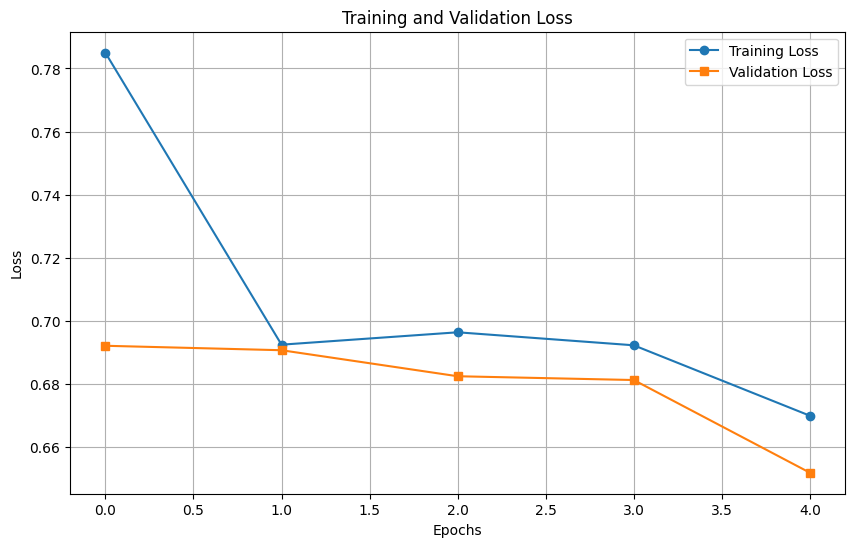


✅ QUESTION 4 COMPLETED SUCCESSFULLY!

📊 Final Results:
  - Training Loss: 0.6700
  - Validation Loss: 0.6519
  - Validation Accuracy: 0.5385


In [1]:
# ============================================
# QUESTION 4: Train and Evaluate a Keras-Based Classifier
# COMPLETE SELF-CONTAINED COLAB NOTEBOOK
# ============================================

import os
import numpy as np
import random
import cv2
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

print("="*60)
print("QUESTION 4: Train and Evaluate a Keras-Based Classifier")
print("="*60)

# ============================================
# STEP 1: Create sample dataset
# ============================================

print("\n📁 Creating sample dataset...")

def create_sample_dataset():
    os.makedirs('./images_dataSAT/class_0_non_agri/', exist_ok=True)
    os.makedirs('./images_dataSAT/class_1_agri/', exist_ok=True)

    for i in range(30):
        img = np.random.randint(0, 255, (84, 80, 3), dtype=np.uint8)
        if i % 2 == 0:
            img[20:60, 30:50] = [200, 200, 200]
        cv2.imwrite(f'./images_dataSAT/class_0_non_agri/non_agri_{i:03d}.png', img)

    for i in range(35):
        img = np.random.randint(0, 255, (84, 80, 3), dtype=np.uint8)
        for _ in range(5):
            x = random.randint(0, 70)
            y = random.randint(0, 74)
            img[y:y+10, x:x+10] = [50, 200, 50]
        cv2.imwrite(f'./images_dataSAT/class_1_agri/agri_{i:03d}.png', img)

    print("✅ Sample dataset created!")

if not os.path.exists('./images_dataSAT'):
    create_sample_dataset()
else:
    print("✅ Dataset already exists!")

# ============================================
# Task 1: Create list fnames of all image files
# ============================================

print("\n" + "="*50)
print("Task 1: Create list of all image files")
print("="*50)

dataset_path = './images_dataSAT/'
fnames = []
for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.endswith(('.jpg', '.png', '.jpeg')):
            fnames.append(os.path.join(root, file))

print(f"Total images: {len(fnames)}")

# ============================================
# Task 2: Create validation_generator
# ============================================

print("\n" + "="*50)
print("Task 2: Create validation generator")
print("="*50)

train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(80, 84),
    batch_size=8,
    class_mode='binary',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(80, 84),
    batch_size=8,
    class_mode='binary',
    subset='validation'
)

print(f"Training samples: {train_generator.samples}")
print(f"Validation samples: {validation_generator.samples}")

# ============================================
# Task 3: Count total number of CNN model layers
# ============================================

print("\n" + "="*50)
print("Task 3: Count total layers")
print("="*50)

model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(80, 84, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

print(f"Total layers: {len(model.layers)}")

# ============================================
# Task 4: Create and compile CNN
# ============================================

print("\n" + "="*50)
print("Task 4: Compile CNN model")
print("="*50)

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
print("✅ Model compiled successfully!")

# ============================================
# Task 5: Define checkpoint callback
# ============================================

print("\n" + "="*50)
print("Task 5: Define checkpoint callback")
print("="*50)

checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    'best_model.h5',
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    verbose=1
)
print("✅ Checkpoint callback defined!")

# ============================================
# Task 6: Train and plot loss
# ============================================

print("\n" + "="*50)
print("Task 6: Train and plot loss")
print("="*50)

print("\n🔄 Training model...")
history = model.fit(
    train_generator,
    epochs=5,
    validation_data=validation_generator,
    callbacks=[checkpoint_callback],
    verbose=1
)

plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='s')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.grid(True)
plt.show()

# ============================================
# Summary
# ============================================

print("\n" + "="*50)
print("✅ QUESTION 4 COMPLETED SUCCESSFULLY!")
print("="*50)
print(f"\n📊 Final Results:")
print(f"  - Training Loss: {history.history['loss'][-1]:.4f}")
print(f"  - Validation Loss: {history.history['val_loss'][-1]:.4f}")
print(f"  - Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")